<a href="https://colab.research.google.com/github/Kranthi2201k/ML-lab/blob/main/4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy before tuning: 0.6


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Accuracy after tuning: 0.6
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


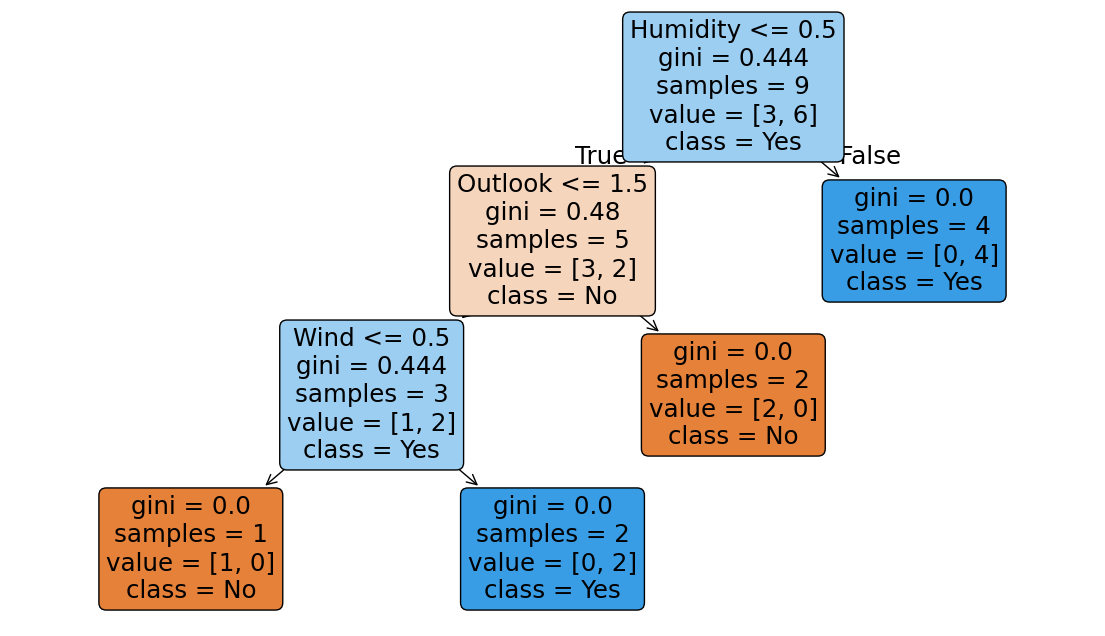

In [2]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
# ---------------------------------------------------------------------------------
# Step 1: Create the "Whether to Play" dataset
# ---------------------------------------------------------------------------------
data = {
'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast',
'Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool',
'Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
'Humidity': ['High','High','High','High','Normal','Normal','Normal',
'High','Normal','Normal','Normal','High','Normal','High'],
'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong',
'Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
'Play': ['No','No','Yes','Yes','Yes','No','Yes',
'No','Yes','Yes','Yes','Yes','Yes','No']
}
# Convert dictionary to DataFrame
df = pd.DataFrame(data)
# ---------------------------------------------
# Step 2: Encode categorical variables
# ---------------------------------------------
le = LabelEncoder()
for column in df.columns:
    df[column] = le.fit_transform(df[column])
# ---------------------------------------------
# Step 3: Split features and target
# ---------------------------------------------
X = df.drop('Play', axis=1) # Input features
y = df['Play'] # Target variable
# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42
)
# ---------------------------------------------
# Step 4: Train a basic Decision Tree
# ---------------------------------------------
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
# Predict and evaluate
y_pred = dt.predict(X_test)
print("Accuracy before tuning:", accuracy_score(y_test, y_pred))
# ---------------------------------------------
# Step 5: Hyperparameter tuning using GridSearchCV
# ---------------------------------------------
param_grid = {
'criterion': ['gini', 'entropy'],
'max_depth': [None, 2, 4, 6],
'min_samples_split': [2, 5, 10],
'min_samples_leaf': [1, 2, 4]
}
grid = GridSearchCV(
DecisionTreeClassifier(random_state=42),
param_grid,
cv=5,
scoring='accuracy'
)
# Train grid search model
grid.fit(X_train, y_train)
# ---------------------------------------------
# Step 6: Train Decision Tree with best parameters
# ---------------------------------------------
best_dt = grid.best_estimator_
y_pred_tuned = best_dt.predict(X_test)
print("Accuracy after tuning:", accuracy_score(y_test, y_pred_tuned))
print("Best Parameters:", grid.best_params_)
# ---------------------------------------------
# Step 7: Visualize the tuned Decision Tree
# ---------------------------------------------
plt.figure(figsize=(14, 8))
plot_tree(
best_dt,
feature_names=X.columns,
class_names=['No', 'Yes'],
filled=True,
rounded=True
)
plt.show()